In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("blood_cell_anomaly_detection.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   cell_id                                  5880 non-null   object 
 1   cell_type                                5880 non-null   object 
 2   anomaly_label                            5880 non-null   int64  
 3   disease_category                         5880 non-null   object 
 4   cell_diameter_um                         5880 non-null   float64
 5   nucleus_area_pct                         5880 non-null   float64
 6   chromatin_density                        5880 non-null   float64
 7   cytoplasm_ratio                          5880 non-null   float64
 8   circularity                              5880 non-null   float64
 9   eccentricity                             5880 non-null   float64
 10  granularity_score                        5880 no

In [3]:
df.describe()

,anomaly_label,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,...,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,...,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.319728,10.176267,43.537976,0.391394,0.564173,0.769263,0.365458,1.882109,1.769252,0.842866,...,13.547194,41.021956,249792.623469,88.942211,33.495867,76.006803,336.235374,0.317583,0.853243,0.866370
std,0.466411,3.642051,33.419390,0.310006,0.335282,0.158219,0.201501,1.428336,1.229362,0.096033,...,2.025136,5.484636,79472.676228,9.927005,1.480168,25.032178,111.922015,0.349655,0.106589,0.094065
min,0.000000,1.000000,0.000000,0.000000,0.050000,0.100000,0.000000,0.000000,1.000000,0.290000,...,5.400000,20.300000,20000.000000,60.000000,28.000000,40.000000,224.000000,0.000000,0.417300,0.471700
25%,0.000000,7.630000,0.000000,0.000000,0.276000,0.711000,0.214750,0.670000,1.000000,0.784000,...,12.200000,37.300000,194653.250000,82.300000,32.500000,60.000000,224.000000,0.063675,0.799000,0.817250
50%,0.000000,10.055000,54.500000,0.479500,0.452000,0.805000,0.331000,1.320000,1.000000,0.854000,...,13.500000,41.000000,250070.500000,88.900000,33.500000,100.000000,256.000000,0.113150,0.877450,0.883400
75%,1.000000,12.860000,72.300000,0.635000,1.000000,0.879000,0.456000,2.980000,2.300000,0.918000,...,14.900000,44.800000,303863.500000,95.700000,34.500000,100.000000,360.000000,0.743850,0.929350,0.934000
max,1.000000,21.180000,99.000000,1.000000,1.000000,1.000000,0.990000,6.000000,7.200000,1.000000,...,20.000000,60.000000,543084.000000,120.000000,38.000000,100.000000,512.000000,1.000000,1.000000,1.000000


In [4]:
df.head()

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [5]:
df["disease_category"].value_counts()

disease_category
Normal_WBC            2800
Normal_RBC             900
Anemia                 650
Leukemia               460
Infection              450
Normal_Platelet        300
Artefact               180
Sickle_Cell_Anemia     140
Name: count, dtype: int64

In [6]:
# Burada önemsiz column'ların listesini çıkartıyoruz.
unimportant_columns = [
    'cell_id', 'anomaly_label', 'mean_r', 'mean_g', 'mean_b', 
    'stain_intensity', 'dataset_source', 'staining_protocol', 
    'microscope_model', 'magnification_x', 'image_resolution_px',
    'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence',
    'labeller_confidence_score'
]

In [7]:
#Burda da dropluyoruz.
df.drop(unimportant_columns, inplace=True,axis=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cell_type                  5880 non-null   object 
 1   disease_category           5880 non-null   object 
 2   cell_diameter_um           5880 non-null   float64
 3   nucleus_area_pct           5880 non-null   float64
 4   chromatin_density          5880 non-null   float64
 5   cytoplasm_ratio            5880 non-null   float64
 6   circularity                5880 non-null   float64
 7   eccentricity               5880 non-null   float64
 8   granularity_score          5880 non-null   float64
 9   lobularity_score           5880 non-null   float64
 10  membrane_smoothness        5880 non-null   float64
 11  cell_area_px               5880 non-null   int64  
 12  perimeter_px               5880 non-null   int64  
 13  patient_age_group          5880 non-null   objec

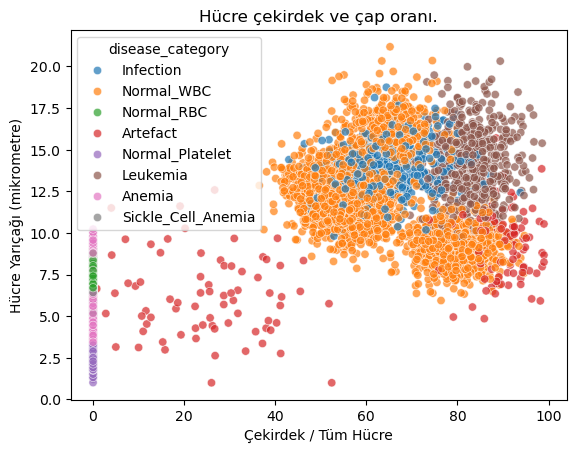

In [9]:
sns.scatterplot(
    data = df,
    x = df["nucleus_area_pct"] ,
    y = df["cell_diameter_um"] ,
    hue = df["disease_category"],
    alpha = 0.7
)
plt.title("Hücre çekirdek ve çap oranı.")
plt.xlabel("Çekirdek / Tüm Hücre")
plt.ylabel("Hücre Yarıçağı (mikrometre)")
plt.show()

In [10]:
df.head()

,cell_type,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,...,perimeter_px,patient_age_group,patient_sex,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl
0,Hypersegmented_Neutrophil,Infection,15.18,58.8,0.542,0.301,0.563,0.529,4.11,6.6,...,90,Elderly,F,6352,4.44,11.7,43.4,257383,85.5,31.4
1,Hypersegmented_Neutrophil,Infection,16.47,73.6,0.583,0.365,0.859,0.443,2.50,6.3,...,61,Elderly,M,7709,4.90,13.9,42.2,302274,92.5,35.0
2,Neutrophil,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,3.01,3.2,...,52,Adult,M,7451,5.72,16.1,39.2,229996,76.3,33.0
3,Normal_RBC,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,0.43,1.0,...,39,Adult,F,9196,3.42,14.6,54.1,130720,92.3,32.5
4,Normal_RBC,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,0.51,1.0,...,50,Elderly,M,5898,5.36,14.6,36.7,228652,83.9,33.4


In [11]:
y = df["disease_category"].values

In [12]:
df = df.drop("disease_category",axis=1)
df

,cell_type,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,...,perimeter_px,patient_age_group,patient_sex,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl
0,Hypersegmented_Neutrophil,15.18,58.8,0.542,0.301,0.563,0.529,4.11,6.6,0.800,...,90,Elderly,F,6352,4.44,11.7,43.4,257383,85.5,31.4
1,Hypersegmented_Neutrophil,16.47,73.6,0.583,0.365,0.859,0.443,2.50,6.3,0.737,...,61,Elderly,M,7709,4.90,13.9,42.2,302274,92.5,35.0
2,Neutrophil,13.41,55.5,0.448,0.376,0.781,0.407,3.01,3.2,0.790,...,52,Adult,M,7451,5.72,16.1,39.2,229996,76.3,33.0
3,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,0.43,1.0,0.937,...,39,Adult,F,9196,3.42,14.6,54.1,130720,92.3,32.5
4,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,0.51,1.0,0.925,...,50,Elderly,M,5898,5.36,14.6,36.7,228652,83.9,33.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,Platelet,2.30,0.0,0.000,1.000,0.699,0.536,1.54,1.0,0.681,...,20,Adult,F,8894,5.37,12.7,37.3,310767,81.4,34.2
5876,Target_Cell,8.80,0.0,0.000,1.000,0.831,0.199,1.12,1.0,0.920,...,44,Adult,M,5499,4.12,17.1,33.2,180228,88.1,34.4
5877,Target_Cell,9.57,0.0,0.000,1.000,0.900,0.320,1.07,1.0,0.954,...,43,Elderly,F,9606,5.44,15.9,45.7,293938,86.7,34.0
5878,Hypersegmented_Neutrophil,11.98,67.8,0.528,0.309,0.752,0.505,3.46,4.7,0.773,...,87,Adult,M,8021,5.19,13.8,42.1,298582,96.5,32.9


In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
y

array([2, 2, 6, ..., 0, 2, 6], shape=(5880,))

In [32]:
le = LabelEncoder()
y = le.fit_transform(y)
y

array([2, 2, 6, ..., 0, 2, 6], shape=(5880,))

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cell_type                  5880 non-null   int64  
 1   cell_diameter_um           5880 non-null   float64
 2   nucleus_area_pct           5880 non-null   float64
 3   chromatin_density          5880 non-null   float64
 4   cytoplasm_ratio            5880 non-null   float64
 5   circularity                5880 non-null   float64
 6   eccentricity               5880 non-null   float64
 7   granularity_score          5880 non-null   float64
 8   lobularity_score           5880 non-null   float64
 9   membrane_smoothness        5880 non-null   float64
 10  cell_area_px               5880 non-null   int64  
 11  perimeter_px               5880 non-null   int64  
 12  patient_age_group          5880 non-null   int64  
 13  patient_sex                5880 non-null   int64

In [34]:
df["patient_age_group"].value_counts()

patient_age_group
1    3276
2    1455
0    1149
Name: count, dtype: int64

In [35]:
age_mapping = {
    'Pediatric': 0,
    'Adult'    : 1,
    'Elderly'  : 2,
}
df['patient_age_group'] = df['patient_age_group'].map(age_mapping)

In [36]:
object_columns = df.select_dtypes(include='object').columns

In [37]:
for i in object_columns:
    df[i] = le.fit_transform(df[i])

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cell_type                  5880 non-null   int64  
 1   cell_diameter_um           5880 non-null   float64
 2   nucleus_area_pct           5880 non-null   float64
 3   chromatin_density          5880 non-null   float64
 4   cytoplasm_ratio            5880 non-null   float64
 5   circularity                5880 non-null   float64
 6   eccentricity               5880 non-null   float64
 7   granularity_score          5880 non-null   float64
 8   lobularity_score           5880 non-null   float64
 9   membrane_smoothness        5880 non-null   float64
 10  cell_area_px               5880 non-null   int64  
 11  perimeter_px               5880 non-null   int64  
 12  patient_age_group          0 non-null      float64
 13  patient_sex                5880 non-null   int64

In [39]:
x = df.values
x

array([[5.00000e+00, 1.51800e+01, 5.88000e+01, ..., 2.57383e+05,
        8.55000e+01, 3.14000e+01],
       [5.00000e+00, 1.64700e+01, 7.36000e+01, ..., 3.02274e+05,
        9.25000e+01, 3.50000e+01],
       [8.00000e+00, 1.34100e+01, 5.55000e+01, ..., 2.29996e+05,
        7.63000e+01, 3.30000e+01],
       ...,
       [1.70000e+01, 9.57000e+00, 0.00000e+00, ..., 2.93938e+05,
        8.67000e+01, 3.40000e+01],
       [5.00000e+00, 1.19800e+01, 6.78000e+01, ..., 2.98582e+05,
        9.65000e+01, 3.29000e+01],
       [8.00000e+00, 1.25800e+01, 5.10000e+01, ..., 3.06735e+05,
        8.27000e+01, 3.25000e+01]], shape=(5880, 21))

In [40]:
x_train, x_test, y_train, y_test, = train_test_split(x,y,train_size=0.8,random_state=42,stratify=y)

In [41]:
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [42]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

torch.Size([4704, 21]) torch.Size([1176, 21]) torch.Size([4704, 1]) torch.Size([1176, 1])


In [44]:
class BloodClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(21,25),
            nn.GELU(),
            nn.Linear(25,25),
            nn.GELU(),
            nn.Linear(25,7)
        )
    def forward(self, x):
        return self.linear_layer_stack(x)

In [45]:
model = BloodClassification()

In [46]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= 0.003)

In [ ]:
from torchmetrics import 